# 1.3.2 - Best dimensionality reduction

The objective is to reduce the 6-dimensional meteorological data to dimension 2 and 3, visualize the projections, and determine which method separates the classes best.

This notebook compares **two dimensionality reduction methods**:
- **PCA**: linear baseline,
- **Kernel PCA (RBF kernel)**: nonlinear alternative.

To make the notion of separation concrete, the notebook also trains a simple **logistic regression benchmark** on the reduced components only. This gives a direct way to compare how predictive each reduced representation is.


In [1]:
import numpy as np
import matplotlib.pyplot as plt

from mpl_toolkits.mplot3d import Axes3D  # noqa: F401
from sklearn.decomposition import PCA, KernelPCA
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X = np.load('data/dimensionality_reduction/data.npy')
y = np.load('data/dimensionality_reduction/labels.npy')

print('Data shape:', X.shape)
print('Label counts:', np.unique(y, return_counts=True))


Data shape: (800, 6)
Label counts: (array([0., 1.]), array([467, 333]))


## Preprocessing and evaluation protocol

The raw features have different scales, so we standardize them before projection.

Then, for each method and each target dimension (`2` and `3`), we evaluate the reduced representation with a simple logistic regression classifier. This is not the final goal of the exercise, but it is a practical benchmark for the sentence *"the projected components should allow to predict the label"*.


In [2]:
X_scaled = StandardScaler().fit_transform(X)
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.25, random_state=42, stratify=y
)

methods = {
    'PCA': lambda n: PCA(n_components=n, random_state=42),
    'KernelPCA (RBF)': lambda n: KernelPCA(n_components=n, kernel='rbf', gamma=0.1, fit_inverse_transform=False)
}

projections = {}
rows = []

for method_name, builder in methods.items():
    for n_components in [2, 3]:
        reducer = builder(n_components)
        X_train_red = reducer.fit_transform(X_train)
        X_test_red = reducer.transform(X_test)

        clf = LogisticRegression(max_iter=5000)
        clf.fit(X_train_red, y_train)
        y_pred = clf.predict(X_test_red)
        acc = accuracy_score(y_test, y_pred)

        projections[(method_name, n_components)] = {
            'reducer': reducer,
            'train': X_train_red,
            'test': X_test_red
        }
        rows.append({
            'method': method_name,
            'n_components': n_components,
            'logreg_accuracy': acc
        })


In [3]:
import pandas as pd

scores_df = pd.DataFrame(rows).sort_values(['logreg_accuracy', 'n_components'], ascending=[False, True])
best_projection = scores_df.iloc[0]

print('FINAL CONCLUSION')
print(
    f"Best method: {best_projection['method']} with {int(best_projection['n_components'])} components "
    f"(logistic regression accuracy on reduced space = {best_projection['logreg_accuracy']:.4f})."
)

scores_df


FINAL CONCLUSION
Best method: PCA with 3 components (logistic regression accuracy on reduced space = 0.9350).


,method,n_components,logreg_accuracy
1,PCA,3,0.935
2,KernelPCA (RBF),2,0.810
0,PCA,2,0.805
3,KernelPCA (RBF),3,0.805


## 2D projections

Each point is colored by the original label:
- `0`: no tempest,
- `1`: tempest.

The goal is to see whether the two classes become visually separable after reduction.


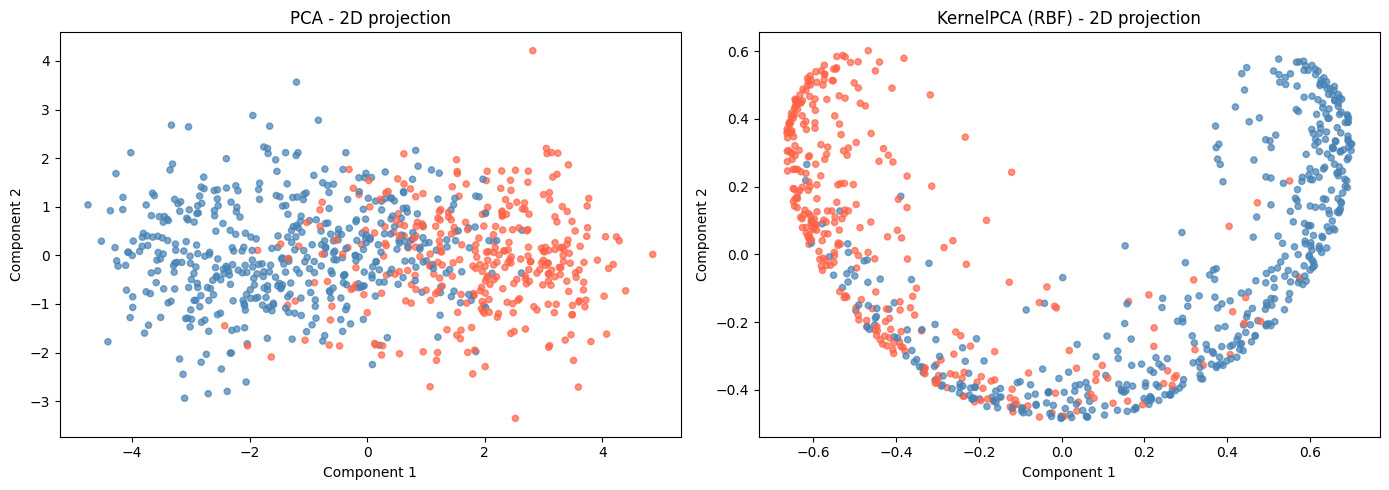

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
colors = np.where(y == 1, 'tomato', 'steelblue')

for ax, method_name in zip(axes, methods.keys()):
    reducer = methods[method_name](2)
    X_2d = reducer.fit_transform(X_scaled)
    ax.scatter(X_2d[:, 0], X_2d[:, 1], c=colors, s=20, alpha=0.7)
    ax.set_title(f'{method_name} - 2D projection')
    ax.set_xlabel('Component 1')
    ax.set_ylabel('Component 2')

plt.tight_layout()
plt.show()


## 3D projections

The same idea is repeated in dimension 3. This is useful because some methods may not separate the classes well in 2D but may become clearer in 3D.


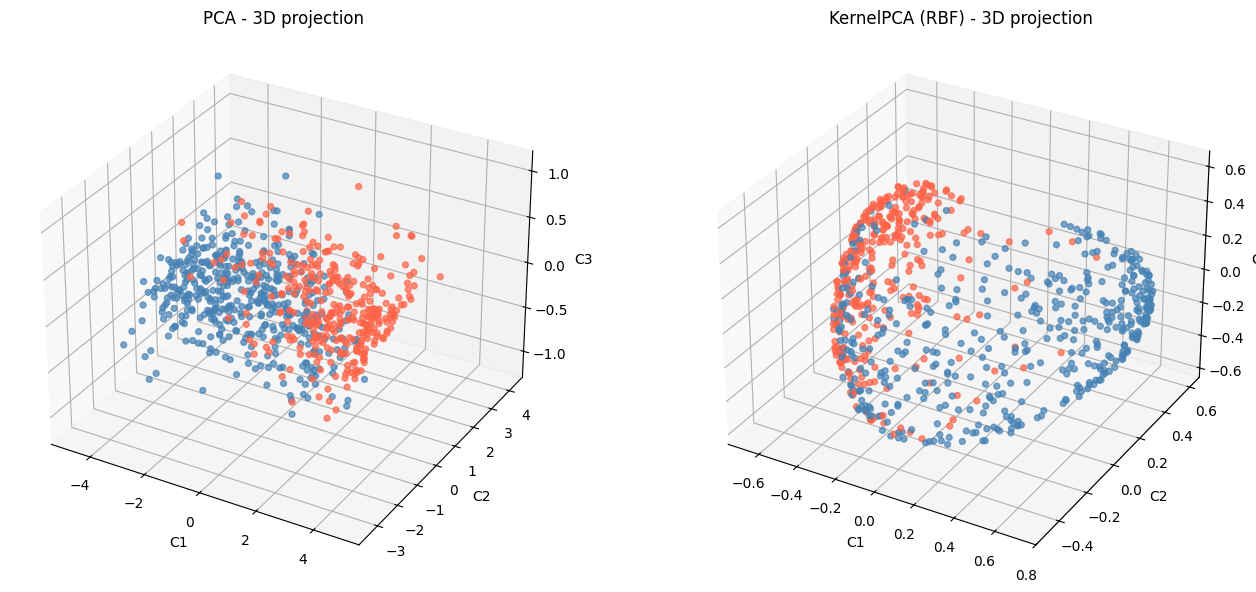

In [5]:
fig = plt.figure(figsize=(14, 6))

for idx, method_name in enumerate(methods.keys(), start=1):
    reducer = methods[method_name](3)
    X_3d = reducer.fit_transform(X_scaled)
    ax = fig.add_subplot(1, 2, idx, projection='3d')
    ax.scatter(X_3d[:, 0], X_3d[:, 1], X_3d[:, 2], c=colors, s=18, alpha=0.7)
    ax.set_title(f'{method_name} - 3D projection')
    ax.set_xlabel('C1')
    ax.set_ylabel('C2')
    ax.set_zlabel('C3')

plt.tight_layout()
plt.show()


## Interpretation

The benchmark table and the scatter plots should be read together:
- the **plots** show whether the classes seem visually separated,
- the **logistic regression score** checks whether this apparent separation is actually predictive.

This is useful because a visually attractive projection is not always the one that gives the best predictive structure.


## Conclusion

The best method is the one that produces the clearest separation **and** the highest logistic regression accuracy on the reduced coordinates.

In practice:
- if PCA wins, then the structure is mostly linear and a simple linear reduction is enough;
- if Kernel PCA wins, then the dataset contains a nonlinear geometry that the linear baseline does not capture as well.

The first analysis cell prints the final recommendation automatically once the notebook is executed.
